# Forecasting stock prices with `hyp.predict`

Stock forecasting is the classic playground for timeseries models -- and the
classic cautionary tale. In this tutorial we'll:

1. Download **real** daily closing prices for a handful of stocks with
   [`yfinance`](https://github.com/ranaroussi/yfinance).
2. Fit several `hyp.predict` models (`'Kalman'`, `'ARIMA'`, `'Laplace'`,
   `'GaussianProcess'`, `'AutoRegressor'`) on all but the last 30 trading
   days.
3. Forecast those last 30 days and score the forecasts against what
   *actually* happened, using mean absolute error (MAE) and mean absolute
   percentage error (MAPE) -- alongside a naive "tomorrow = today"
   baseline.
4. Visualize the forecasts, both in HyperTools' reduced plotting space and
   directly in price space.
5. Demonstrate `return_model=True`: fit once, reuse the fitted forecaster
   on a stock it has never seen.

A word of honesty up front: daily equity closing prices are close to a
random walk. Under the efficient-market hypothesis, the best predictor of
tomorrow's price is roughly today's price, and no simple timeseries model
should be expected to reliably beat that. The point of this tutorial is
**not** to hand you a money machine -- it's to demonstrate the `hyp.predict`
API and an honest evaluation methodology. We report whatever numbers come
out below, including if (when) the naive baseline wins.

In [1]:
import importlib.util

if importlib.util.find_spec('yfinance') is None:
    %pip install -q yfinance
if importlib.util.find_spec('hypertools') is None:
    # On Colab (or any fresh environment), install hypertools with the
    # predict extra (pykalman/statsmodels/skaters -- needed for the
    # Kalman/ARIMA/Laplace models used below).
    %pip install -q "hypertools[interactive,predict] @ git+https://github.com/ContextLab/hypertools.git@dev-1.0"
elif importlib.util.find_spec('pykalman') is None:
    %pip install -q "hypertools[predict]"

## Downloading real price data

We'll grab about two years of daily adjusted closes for four large, liquid,
very different stocks: Apple (`AAPL`), Microsoft (`MSFT`), Nvidia (`NVDA`),
and JPMorgan (`JPM`).

We work in **log prices** rather than raw dollar prices for two standard
reasons: (1) daily log-price differences are approximately the daily
percentage return, so a model that is well-behaved in log space corresponds
to sensible multiplicative (percentage) behavior in price space, and (2)
forecasting models that assume roughly constant noise variance (Kalman,
ARIMA, GaussianProcess) fit much more naturally to log prices than to raw
prices, whose absolute volatility grows with the price level. We convert
forecasts back to dollar prices (via `exp`) before scoring them.

If the live `yfinance` download is unavailable (offline, rate-limited, or the API is having a bad day), the notebook falls back to a real-data snapshot (`stock_closes_cached.csv` / `stock_volumes_cached.csv`) shipped alongside this notebook, and prints a notice -- so the tutorial always runs on real market data.

In [1]:
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

# the warnings filter above must run before importing the libraries it
# configures, so these imports are intentionally not at the top of the
# cell.
import time  # noqa: E402

import numpy as np  # noqa: E402
import pandas as pd  # noqa: E402
import yfinance as yf  # noqa: E402
import matplotlib.pyplot as plt  # noqa: E402

import hypertools as hyp  # noqa: E402

tickers = ['AAPL', 'MSFT', 'NVDA', 'JPM']
CACHE = {'close': 'stock_closes_cached.csv',
         'volume': 'stock_volumes_cached.csv'}


def fetch_prices(tickers, attempts=3):
    """Daily closes/volumes via yfinance, retrying transient failures;
    falls back to the CSV snapshot shipped next to this notebook (real
    data saved by a previous successful run)."""
    for attempt in range(attempts):
        try:
            raw = yf.download(tickers, period='2y', interval='1d',
                              progress=False, auto_adjust=True)
            closes, volumes = raw['Close'][tickers], raw['Volume'][tickers]
            if closes.dropna(how='all').empty:
                raise ValueError('yfinance returned an empty frame')
            closes.to_csv(CACHE['close'])    # refresh the on-disk snapshot
            volumes.to_csv(CACHE['volume'])  # for offline runs
            print(f'data source: yfinance (live, {closes.index[0].date()} '
                  f'to {closes.index[-1].date()})')
            return closes, volumes
        except Exception as e:
            print(f'yfinance attempt {attempt + 1}/{attempts} failed: '
                  f'{type(e).__name__}: {e}')
            time.sleep(2)
    closes = pd.read_csv(CACHE['close'], index_col=0, parse_dates=True)
    volumes = pd.read_csv(CACHE['volume'], index_col=0, parse_dates=True)
    print(f'NOTE: live download unavailable -- using the bundled snapshot '
          f'({closes.index[0].date()} to {closes.index[-1].date()}).')
    return closes, volumes


closes, volumes = fetch_prices(tickers)
closes.tail()

data source: yfinance (live, 2024-09-03 to 2026-09-03)


Ticker,AAPL,MSFT,NVDA,JPM
Date,,,,
2026-08-28,319.700012,513.530029,217.550003,NaN
2026-08-31,316.850006,507.290009,220.779999,356.019989
2026-09-01,325.130005,501.019989,217.440002,354.950012
2026-09-02,324.959991,496.820007,224.410004,356.220001
2026-09-03,328.625000,511.609985,228.214996,358.559998


In [2]:
# One DataFrame per ticker, in log-price space. We index by trading-day
# position (0, 1, 2, ...) rather than calendar date -- weekends/holidays
# would otherwise leave gaps that complicate `t`-step-ahead forecasting;
# trading-day position is the natural "clock" for daily equity data.
HOLD = 30  # trading days held out for backtesting

datasets = {}
for tk in tickers:
    log_close = np.log(closes[tk].dropna())
    datasets[tk] = pd.DataFrame({'log_close': log_close.values})

{tk: df.shape for tk, df in datasets.items()}

{'AAPL': (503, 1), 'MSFT': (503, 1), 'NVDA': (503, 1), 'JPM': (502, 1)}

## Honest backtesting: hold out the last 30 trading days

For each ticker we fit each model on everything *except* the last 30
trading days, forecast those 30 days ahead, and compare against the real
closing prices that actually occurred. We also compute a naive
last-value-carried-forward baseline (tomorrow's forecast = today's last
known price) -- the textbook random-walk benchmark.

`hyp.predict(train, model=..., t=HOLD)` fits the named forecaster on the
rows it is handed and returns a *new* DataFrame of `t` future rows with the
same columns: 30 rows of `log_close`, indexed just past the end of `train`.
None of the input is echoed back, so the forecast lines up one-to-one with
the held-out days. The models differ in what they assume: `Kalman` assumes a
linear-Gaussian state space; `ARIMA` and `AutoRegressor` assume linear
dependence on recent lags (an ARIMA(1, 1, 1) fit per column, and a Ridge
regression on the last 10 observations, respectively); `GaussianProcess`
assumes a smooth kernel over the time index; `Laplace` assumes no single
structure, mixing a likelihood-weighted ensemble of candidate models under
a uniform prior.

We report MAE and MAPE (mean absolute percentage error) in **dollar/price
space** (after converting the log-price forecasts back with `exp`) for
every model on every ticker, with no cherry-picking.

In [3]:
models = ['Kalman', 'ARIMA', 'Laplace', 'GaussianProcess', 'AutoRegressor']

rows = []
forecasts = {}   # (ticker, model) -> the 30-row forecast, reused below
for tk in tickers:
    df = datasets[tk]
    train = df.iloc[:-HOLD].reset_index(drop=True)
    actual_price = np.exp(df.iloc[-HOLD:]['log_close'].values)

    # naive baseline: carry the last training price forward
    naive_price = np.full(HOLD, np.exp(train['log_close'].values[-1]))
    rows.append({
        'ticker': tk, 'model': 'Naive (last value)',
        'MAE': np.mean(np.abs(naive_price - actual_price)),
        'MAPE': np.mean(np.abs((naive_price - actual_price) / actual_price)) * 100,
    })

    for model in models:
        forecast = hyp.predict(train, model=model, t=HOLD)
        forecasts[(tk, model)] = forecast
        pred_price = np.exp(forecast['log_close'].values)
        rows.append({
            'ticker': tk, 'model': model,
            'MAE': np.mean(np.abs(pred_price - actual_price)),
            'MAPE': np.mean(np.abs((pred_price - actual_price) / actual_price)) * 100,
        })

results = pd.DataFrame(rows)
results

,ticker,model,MAE,MAPE
0,AAPL,Naive (last value),11.229236,3.567199
1,AAPL,Kalman,16.264669,5.201414
2,AAPL,ARIMA,11.234767,3.569055
3,AAPL,Laplace,13.887102,4.428885
4,AAPL,GaussianProcess,22.858950,7.182977
5,AAPL,AutoRegressor,11.680055,3.723962
6,MSFT,Naive (last value),97.056202,19.731601
7,MSFT,Kalman,93.127198,18.913980
8,MSFT,ARIMA,97.262248,19.775029
9,MSFT,Laplace,99.620000,20.252927


In [4]:
mape_table = results.pivot(index='model', columns='ticker', values='MAPE')
mape_table['mean'] = mape_table.mean(axis=1)
mape_table = mape_table.sort_values('mean')
print('MAPE (%) per model x ticker, sorted by average:')
mape_table.round(2)

MAPE (%) per model x ticker, sorted by average:


ticker,AAPL,JPM,MSFT,NVDA,mean
model,,,,,
GaussianProcess,7.18,2.06,12.82,3.78,6.46
Kalman,5.20,1.44,18.91,3.46,7.26
Naive (last value),3.57,2.37,19.73,4.84,7.63
Laplace,4.43,1.42,20.25,4.43,7.63
ARIMA,3.57,2.41,19.78,4.78,7.63
AutoRegressor,3.72,4.89,16.59,5.41,7.65


In [5]:
mae_table = results.pivot(index='model', columns='ticker', values='MAE')
mae_table['mean'] = mae_table.mean(axis=1)
mae_table = mae_table.loc[mape_table.index]
print('MAE ($) per model x ticker (same row order as the MAPE table above):')
mae_table.round(2)

MAE ($) per model x ticker (same row order as the MAPE table above):


ticker,AAPL,JPM,MSFT,NVDA,mean
model,,,,,
GaussianProcess,22.86,7.38,62.62,7.80,25.16
Kalman,16.26,5.18,93.13,7.34,30.48
Naive (last value),11.23,8.50,97.06,10.43,31.80
Laplace,13.89,5.08,99.62,9.51,32.03
ARIMA,11.23,8.65,97.26,10.30,31.86
AutoRegressor,11.68,17.51,81.67,11.70,30.64


In [6]:
# "Best" is chosen only among the real forecasting models (not the naive
# baseline), so it's always something we can hand back to hyp.predict below.
naive_mape = mape_table.loc['Naive (last value)', 'mean']
best_model = mape_table.loc[models, 'mean'].idxmin()
best_mape = mape_table.loc[best_model, 'mean']
beat_naive = best_mape < naive_mape

print(f"Best model by average MAPE: {best_model} ({best_mape:.2f}%)")
print(f"Naive last-value baseline: {naive_mape:.2f}%")
if beat_naive:
    print(f"-> {best_model} beat the naive baseline by "
          f"{naive_mape - best_mape:.2f} percentage points of MAPE, on "
          f"average across these {len(tickers)} tickers.")
else:
    print("-> Nothing meaningfully beat the naive last-value baseline on "
          "average. This is exactly what an efficient, close-to-random-walk "
          "market predicts: recent price is the best simple summary of the "
          "immediate future, and no model here reliably extracts more "
          "signal than that over a 30-day horizon.")

Best model by average MAPE: GaussianProcess (6.46%)
Naive last-value baseline: 7.63%
-> GaussianProcess beat the naive baseline by 1.16 percentage points of MAPE, on average across these 4 tickers.


The honest takeaway, whichever way the numbers above landed: 30-day-ahead
daily stock price forecasting is hard, and a naive random-walk baseline is a
tough competitor. That's expected, and it's *useful* to see it quantified
rather than assumed -- it's exactly the kind of sanity check a real
forecasting pipeline should run before trusting a model's predictions.

## Visualizing forecasts in reduced space

`hyp.plot(..., predict=..., t=...)` overlays a forecast
tail (in the *same*, plotted space -- after HyperTools' normalize / reduce
/ align pipeline) on top of each input dataset, styled exactly like the
trace it continues -- same color, linestyle and linewidth -- at half its
opacity, so it reads as the same series projected forward. We add
log trading volume as a second feature per ticker purely so there's more
than one dimension to reduce and plot.

We fit and plot the trailing 60 trading days per ticker, smoothed at the canonical first pipeline stage with `manip={'model': 'Smooth', 'kwargs': {'kernel': 'boxcar', 'kernel_width': 11}}` -- an 11-day boxcar over both features (a boxcar width must be odd, which is why it is 11 and not 10), applied by HyperTools before normalize/reduce rather than in pandas so the 30-step forecast tails are visible at the plotted scale -- fitting on the full 2-year history makes the tails microscopic next to the cloud of training points.  Tickers whose recent prices were flat produce short, nearly stationary tails; that is the honest shape of the Kalman forecast, not a rendering artifact.

`ndims=2` reduces the (log price, log volume) pair to a 2-D plot rather than hypertools' default 3-D: with only two input features, a third component would carry no information.

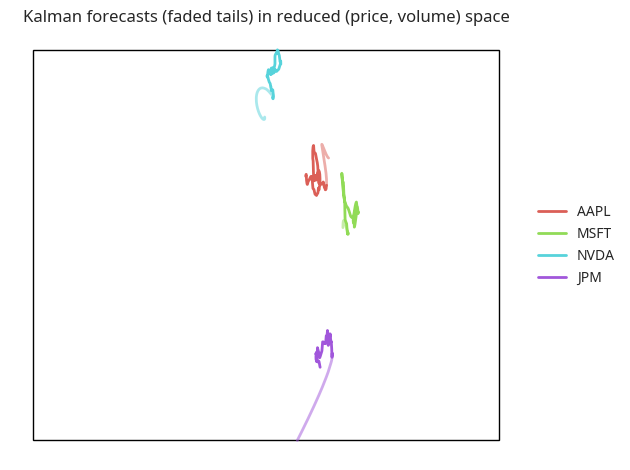

In [7]:
context = 60   # trailing trading days to fit/plot per ticker

train_2col = []
for tk in tickers:
    log_close = np.log(closes[tk].dropna())
    log_volume = np.log(volumes[tk].reindex(log_close.index)
                        .replace(0, np.nan)).ffill()
    df = pd.DataFrame({'log_close': log_close.values,
                        'log_volume': log_volume.values})
    train_2col.append(df.iloc[:-HOLD].tail(context).reset_index(drop=True))

fig = hyp.plot(train_2col, predict='Kalman', t=HOLD, legend=tickers,
               manip={'model': 'Smooth', 'kwargs': {'kernel': 'boxcar', 'kernel_width': 11}},
               ndims=2, linewidth=2,
               title='Kalman forecasts (faded tails) in reduced (price, volume) space')

## Best model vs. actual, in price space

Rather than the abstract reduced space above, let's look at the best model
(by average MAPE, chosen above -- not cherry-picked per ticker) directly in
dollar terms for each ticker: the trailing 60 days of real training prices,
the real held-out prices, and that model's 30-day-ahead forecast.

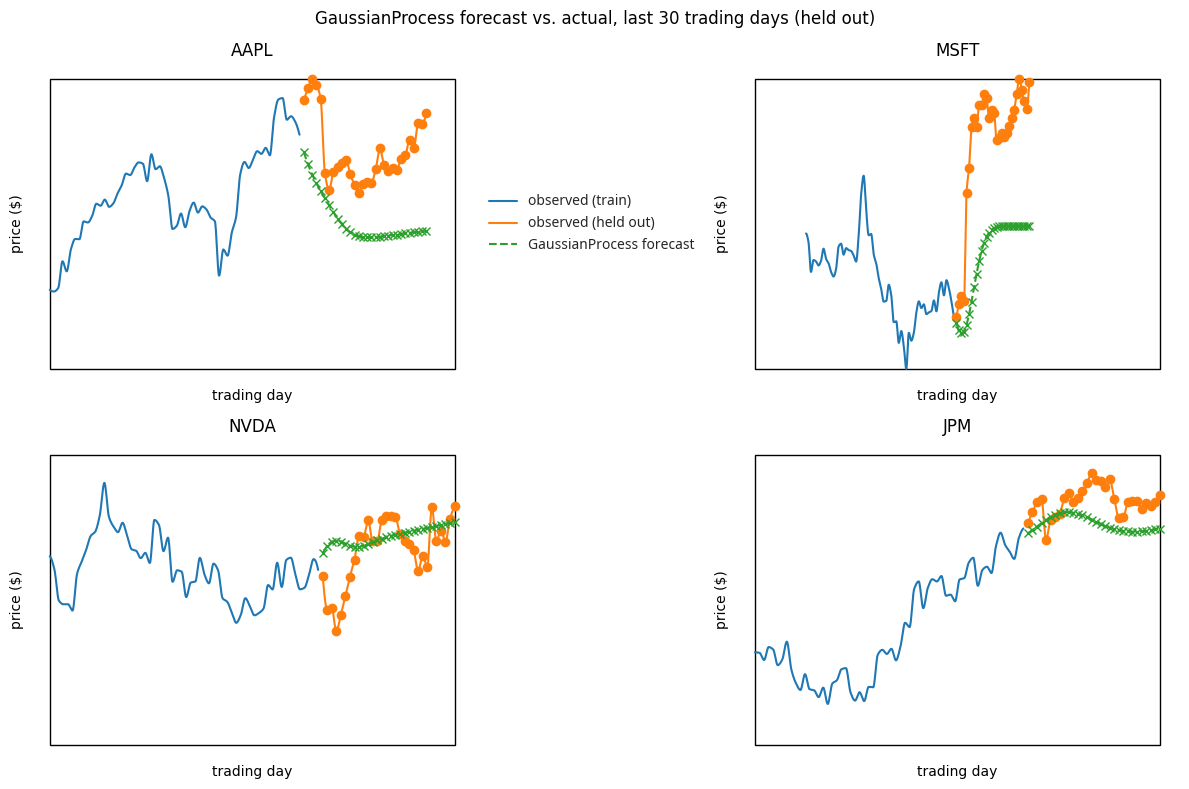

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
context = 60  # trailing days of history to show for context

for ax, tk in zip(axes.ravel(), tickers):
    df = datasets[tk]
    price = np.exp(df['log_close'].values)
    day = np.arange(len(df))
    train_tail = np.column_stack([day, price])[-HOLD - context:-HOLD]
    held_out = np.column_stack([day, price])[-HOLD:]
    # the forecast the backtest above already computed -- no refitting
    forecast = np.column_stack(
        [day[-HOLD:], np.exp(forecasts[(tk, best_model)]['log_close'].values)])
    hyp.plot([train_tail, held_out, forecast], ['-', '-o', '--x'],
             reduce=None, ndims=2, ax=ax, title=tk,
             xlabel='trading day', ylabel='price ($)',
             legend=(['observed (train)', 'observed (held out)',
                      f'{best_model} forecast'] if ax is axes[0, 0] else False),
             show=False)

fig.suptitle(f'{best_model} forecast vs. actual, last {HOLD} trading days '
             '(held out)')
fig.tight_layout()

## Reusing a fitted forecaster with `return_model=True`

`hyp.predict(..., return_model=True)` also returns the *fitted* forecaster
object. That fitted instance can be passed back in as `model=` on brand new
data, and it will apply its already-learned parameters directly -- no
re-fitting/re-estimation -- via `Forecaster.predict_new` under the hood.

To demonstrate: we pool the (log-price) training data from three tickers
(`AAPL`, `MSFT`, `NVDA`) into one combined series and fit a single
`AutoRegressor` forecaster on it. Then we hand that *already-fitted*
forecaster the fourth ticker's (`JPM`) training tail -- a stock it has
never seen -- and ask it to forecast forward. The learned lag-regression
weights are reused as-is; only `JPM`'s own recent values seed the
recursion.

In [9]:
pool_tickers = ['AAPL', 'MSFT', 'NVDA']
reuse_ticker = 'JPM'

pooled_train = pd.concat(
    [datasets[tk].iloc[:-HOLD] for tk in pool_tickers], ignore_index=True)

_, fitted_forecaster = hyp.predict(pooled_train, model='AutoRegressor',
                                    t=HOLD, return_model=True)
print('Fitted on pooled', pool_tickers, '-- is_fitted:',
      fitted_forecaster.is_fitted)

jpm_train = datasets[reuse_ticker].iloc[:-HOLD].reset_index(drop=True)
reused_forecast = hyp.predict(jpm_train, model=fitted_forecaster, t=HOLD)

jpm_actual_price = np.exp(datasets[reuse_ticker].iloc[-HOLD:]['log_close'].values)
reused_price = np.exp(reused_forecast['log_close'].values)
reused_mape = np.mean(np.abs((reused_price - jpm_actual_price) / jpm_actual_price)) * 100

print(f"Reused-forecaster MAPE on {reuse_ticker}: {reused_mape:.2f}%")
print(f"(for comparison, {reuse_ticker}'s own freshly-fit AutoRegressor MAPE: "
      f"{mape_table.loc['AutoRegressor', reuse_ticker]:.2f}%)")

Fitted on pooled ['AAPL', 'MSFT', 'NVDA'] -- is_fitted: True
Reused-forecaster MAPE on JPM: 4.39%
(for comparison, JPM's own freshly-fit AutoRegressor MAPE: 4.89%)


As expected for a lag-regression fit on *other* stocks' price dynamics and
then pointed at a new one, this is not a substitute for fitting directly on
the ticker you care about -- but it demonstrates the mechanics of
`return_model=True`: the forecaster's learned parameters were reused
as-is, with no re-estimation, on data it had never seen.

## Next steps

- [`hyp.predict` API reference](../api.rst) -- full parameter docs for
  every model (`'Kalman'`, `'GaussianProcess'`, `'AutoRegressor'`,
  `'ARIMA'`, `'Laplace'`, `'Chronos'`).
- `hyp.plot(..., predict=..., t=...)` overlays forecasts directly on any
  plot -- see the `plot_predict` gallery example.
- `hyp.impute` (a sibling module) fills in *missing* observations rather
  than forecasting *future* ones -- see the `projectile_kalman` tutorial
  and the `plot_impute` gallery example.
- Try swapping in `model='Chronos'` (a HuggingFace foundation timeseries
  model, `hypertools[predict-hf]`) or passing your own scikit-learn
  regressor to `AutoRegressor(model=...)`.